In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os
from datetime import datetime

# Pre-define for Pylance
TOP30     = []
TIER_A    = []
TIER_B    = []
FEAT_COLS = []
score_dow = 0.0
score_ml  = 0.0

grid      = pd.read_parquet('../data/processed/daily_sales.parquet')
model     = joblib.load('../models/hgbr_model.pkl')
FEAT_COLS = joblib.load('../models/feat_cols.pkl')
TOP30     = joblib.load('../models/top30_skus.pkl')

print(f'Grid  : {grid.shape}')
print(f'Model : loaded ✓')
print(f'Features : {len(FEAT_COLS)}')
print(f'Top30 : {len(TOP30)} SKUs')

Grid  : (1754, 15972)
Model : loaded ✓
Features : 61
Top30 : 0 SKUs


In [9]:
LAG_DAYS     = [1, 2, 3, 7, 14, 21, 28, 35, 42, 56, 364, 365, 366]
ROLL_WINDOWS = [7, 14, 28, 56, 90]
DOW_LAG_WKS  = [1, 2, 4, 8, 12]

def build_features(d, series):
    hist = series[series.index < d]
    row  = {
        'dow'            : d.dayofweek,
        'month'          : d.month,
        'dom'            : d.day,
        'quarter'        : d.quarter,
        'week'           : int(d.isocalendar().week),
        'is_weekend'     : int(d.dayofweek >= 5),
        'is_tet'         : int((d.month==1 and d.day>=15) or
                               (d.month==2 and d.day<=15)),
        'is_month_end'   : int(d.day >= 25),
        'is_month_start' : int(d.day <= 5),
        'is_q1'          : int(d.month in [1, 2, 3]),
        'is_q2'          : int(d.month in [4, 5, 6]),
        'is_q3'          : int(d.month in [7, 8, 9]),
        'is_q4'          : int(d.month in [10, 11, 12]),
        'is_end_of_q'    : int(d.month in [3, 6, 9, 12] and d.day >= 20),
        'is_start_of_q'  : int(d.month in [1, 4, 7, 10] and d.day <= 10),
    }
    for lag in LAG_DAYS:
        row[f'lag_{lag}'] = float(
            series.get(d - pd.Timedelta(days=lag), 0.0))

    for w in ROLL_WINDOWS:
        win = hist.iloc[-w:] if len(hist) >= w else hist
        row[f'rmean_{w}'] = float(win.mean())
        row[f'rstd_{w}']  = float(win.std()) if len(win) > 1 else 0.
        row[f'rmax_{w}']  = float(win.max())
        row[f'rpos_{w}']  = float((win > 0).mean())

    same_q = hist[hist.index.quarter == d.quarter]
    row['q_mean']    = float(same_q.mean())    if len(same_q) > 0 else 0.
    row['q_std']     = float(same_q.std())     if len(same_q) > 1 else 0.
    row['q_max']     = float(same_q.max())     if len(same_q) > 0 else 0.

    last_yr_q = hist[
        (hist.index.quarter == d.quarter) &
        (hist.index.year    == d.year - 1)
    ]
    row['q_ly_mean'] = float(last_yr_q.mean()) if len(last_yr_q) > 0 else 0.
    row['q_ly_sum']  = float(last_yr_q.sum())  if len(last_yr_q) > 0 else 0.

    same_dow = hist[hist.index.dayofweek == d.dayofweek]
    for wk in DOW_LAG_WKS:
        row[f'dlag_{wk}w'] = float(same_dow.iloc[-wk]) \
                              if len(same_dow) >= wk else 0.

    t28 = hist.iloc[-28:]
    row['trend_28']     = float(
        np.polyfit(np.arange(len(t28)),
                   t28.values.astype(float), 1)[0]
    ) if len(t28) > 2 else 0.
    row['zero_frac_28'] = float(
        (t28 == 0).mean()) if len(t28) > 0 else 1.

    ly     = d - pd.DateOffset(years=1)
    ly_win = hist[
        (hist.index >= ly - pd.Timedelta(days=14)) &
        (hist.index <= ly + pd.Timedelta(days=14))
    ]
    row['ly_mean'] = float(ly_win.mean()) if len(ly_win) > 0 else 0.

    return row

print(f'build_features ready — '
      f'{len(build_features(pd.Timestamp("2025-08-01"), grid[grid.columns[0]]))} features')
LAG_DAYS     = [1, 2, 3, 7, 14, 21, 28, 35, 42, 56, 364, 365, 366]
ROLL_WINDOWS = [7, 14, 28, 56, 90]
DOW_LAG_WKS  = [1, 2, 4, 8, 12]

def build_features(d, series):
    hist = series[series.index < d]
    row  = {
        'dow'            : d.dayofweek,
        'month'          : d.month,
        'dom'            : d.day,
        'quarter'        : d.quarter,
        'week'           : int(d.isocalendar().week),
        'is_weekend'     : int(d.dayofweek >= 5),
        'is_tet'         : int((d.month==1 and d.day>=15) or
                               (d.month==2 and d.day<=15)),
        'is_month_end'   : int(d.day >= 25),
        'is_month_start' : int(d.day <= 5),
        'is_q1'          : int(d.month in [1, 2, 3]),
        'is_q2'          : int(d.month in [4, 5, 6]),
        'is_q3'          : int(d.month in [7, 8, 9]),
        'is_q4'          : int(d.month in [10, 11, 12]),
        'is_end_of_q'    : int(d.month in [3, 6, 9, 12] and d.day >= 20),
        'is_start_of_q'  : int(d.month in [1, 4, 7, 10] and d.day <= 10),
    }
    for lag in LAG_DAYS:
        row[f'lag_{lag}'] = float(
            series.get(d - pd.Timedelta(days=lag), 0.0))

    for w in ROLL_WINDOWS:
        win = hist.iloc[-w:] if len(hist) >= w else hist
        row[f'rmean_{w}'] = float(win.mean())
        row[f'rstd_{w}']  = float(win.std()) if len(win) > 1 else 0.
        row[f'rmax_{w}']  = float(win.max())
        row[f'rpos_{w}']  = float((win > 0).mean())

    same_q = hist[hist.index.quarter == d.quarter]
    row['q_mean']    = float(same_q.mean())    if len(same_q) > 0 else 0.
    row['q_std']     = float(same_q.std())     if len(same_q) > 1 else 0.
    row['q_max']     = float(same_q.max())     if len(same_q) > 0 else 0.

    last_yr_q = hist[
        (hist.index.quarter == d.quarter) &
        (hist.index.year    == d.year - 1)
    ]
    row['q_ly_mean'] = float(last_yr_q.mean()) if len(last_yr_q) > 0 else 0.
    row['q_ly_sum']  = float(last_yr_q.sum())  if len(last_yr_q) > 0 else 0.

    same_dow = hist[hist.index.dayofweek == d.dayofweek]
    for wk in DOW_LAG_WKS:
        row[f'dlag_{wk}w'] = float(same_dow.iloc[-wk]) \
                              if len(same_dow) >= wk else 0.

    t28 = hist.iloc[-28:]
    row['trend_28']     = float(
        np.polyfit(np.arange(len(t28)),
                   t28.values.astype(float), 1)[0]
    ) if len(t28) > 2 else 0.
    row['zero_frac_28'] = float(
        (t28 == 0).mean()) if len(t28) > 0 else 1.

    ly     = d - pd.DateOffset(years=1)
    ly_win = hist[
        (hist.index >= ly - pd.Timedelta(days=14)) &
        (hist.index <= ly + pd.Timedelta(days=14))
    ]
    row['ly_mean'] = float(ly_win.mean()) if len(ly_win) > 0 else 0.

    return row

print(f'build_features ready — '
      f'{len(build_features(pd.Timestamp("2025-08-01"), grid[grid.columns[0]]))} features')

build_features ready — 61 features
build_features ready — 61 features


In [10]:
VAL_DATES  = pd.date_range('2025-08-09', '2025-09-05', freq='D')
train_grid = grid[grid.index < '2025-08-09']
actual     = grid.loc[VAL_DATES]
weights    = train_grid.iloc[-28:].sum()

qty_90d  = train_grid[train_grid.index >= '2025-05-10'].sum()
qty_365d = train_grid[train_grid.index >= '2024-08-09'].sum()
qty_28d  = train_grid[train_grid.index >= '2025-07-12'].sum()

TIER_A = qty_90d[
    (qty_90d  >= 150) &
    (qty_365d >= 400)
].index.tolist()

TIER_B = qty_90d[
    (qty_90d  >= 30)  &
    (qty_365d >= 80)  &
    (~qty_90d.index.isin(TIER_A))
].index.tolist()

active_skus = weights[weights > 0].index.tolist()

print(f'Train  : {train_grid.index[0].date()} → {train_grid.index[-1].date()}')
print(f'Val    : {VAL_DATES[0].date()} → {VAL_DATES[-1].date()}')
print(f'Tier A : {len(TIER_A)} SKUs')
print(f'Tier B : {len(TIER_B)} SKUs')
print(f'Active : {len(active_skus)} SKUs')
print(f'Top 30 : {TOP30[:5]} ...')

Train  : 2020-11-17 → 2025-08-08
Val    : 2025-08-09 → 2025-09-05
Tier A : 125 SKUs
Tier B : 408 SKUs
Active : 2823 SKUs
Top 30 : [] ...


In [11]:
def wrmsse(pred, actual, train, weights):
    mse        = ((pred.values - actual.values) ** 2).mean(axis=0)
    train_mean = train.iloc[-28:].mean(axis=0).values
    scale      = train_mean ** 2 + 1e-8
    rmsse      = np.sqrt(mse / scale)
    w          = weights.values / weights.sum()
    return float((w * rmsse).sum())

print('wrmsse function ready ✓')

wrmsse function ready ✓


In [12]:
def dow_forecast(series, dates, n_weeks=12):
    s = series.copy()
    if series.iloc[-56:].sum() == 0:
        return np.zeros(len(dates))
    preds = []
    for d in dates:
        if d.dayofweek >= 5:
            preds.append(0.0)
            s[d] = 0.0
            continue
        past = s[s.index.dayofweek == d.dayofweek].iloc[-n_weeks:]
        if len(past) > 0 and past.sum() > 0:
            w    = np.exp(np.linspace(-2, 0, len(past)))
            pred = float(np.average(past.values, weights=w))
        else:
            pred = float(s.iloc[-28:].mean())
        pred = max(0.0, pred)
        preds.append(pred)
        s[d] = pred
    return np.array(preds)

print('dow_forecast function ready ✓')

dow_forecast function ready ✓


In [13]:
print(f'Running DOW forecast on {len(active_skus)} active SKUs...')

dow_preds = {}
for i, sku in enumerate(active_skus):
    dow_preds[sku] = dow_forecast(train_grid[sku], VAL_DATES)
    if (i + 1) % 500 == 0:
        print(f'  {i+1}/{len(active_skus)} done...')

pred_dow = pd.DataFrame(0.0, index=VAL_DATES, columns=grid.columns)
for sku in active_skus:
    pred_dow[sku] = dow_preds[sku]

score_dow = wrmsse(pred_dow, actual, train_grid, weights)
print(f'\nDOW avg WRMSSE : {round(score_dow, 4)}')

Running DOW forecast on 2823 active SKUs...
  500/2823 done...
  1000/2823 done...
  1500/2823 done...
  2000/2823 done...
  2500/2823 done...

DOW avg WRMSSE : 2.3823


In [14]:
print(f'Running ML forecast on {len(TIER_A)} Tier A SKUs...')

ml_preds = {}
for i, sku in enumerate(TIER_A):
    series = train_grid[sku].copy()
    preds  = []
    for d in VAL_DATES:
        row  = build_features(d, series[series.index < d])
        Xrow = pd.DataFrame([row], columns=FEAT_COLS).fillna(0)
        pred = max(0.0, float(np.expm1(model.predict(Xrow)[0])))
        preds.append(pred)
        series[d] = pred
    ml_preds[sku] = np.array(preds)

    if (i + 1) % 20 == 0:
        print(f'  {i+1}/{len(TIER_A)} done...')

pred_ml = pd.DataFrame(0.0, index=VAL_DATES, columns=grid.columns)
for sku in TIER_A:
    pred_ml[sku] = ml_preds[sku]

# Fill Tier B with DOW
for sku in TIER_B:
    if sku in dow_preds:
        pred_ml[sku] = dow_preds[sku]

score_ml = wrmsse(pred_ml, actual, train_grid, weights)
print(f'\nML model WRMSSE : {round(score_ml, 4)}')

Running ML forecast on 125 Tier A SKUs...
  20/125 done...
  40/125 done...
  60/125 done...
  80/125 done...
  100/125 done...
  120/125 done...

ML model WRMSSE : 2.1061


In [15]:
print('=' * 50)
print('MODEL COMPARISON')
print('=' * 50)
print(f'DOW avg (baseline) : {round(score_dow, 4)}')
print(f'ML + DOW (tiered)  : {round(score_ml,  4)}')
print('-' * 50)

if score_ml < score_dow:
    print(f'Improvement        : {round(score_dow - score_ml, 4)}')
    print('✅ ML is better — safe to submit')
else:
    print(f'Regression         : {round(score_ml - score_dow, 4)}')
    print('❌ ML is worse — do NOT submit, go back to 06')

MODEL COMPARISON
DOW avg (baseline) : 2.3823
ML + DOW (tiered)  : 2.1061
--------------------------------------------------
Improvement        : 0.2762
✅ ML is better — safe to submit


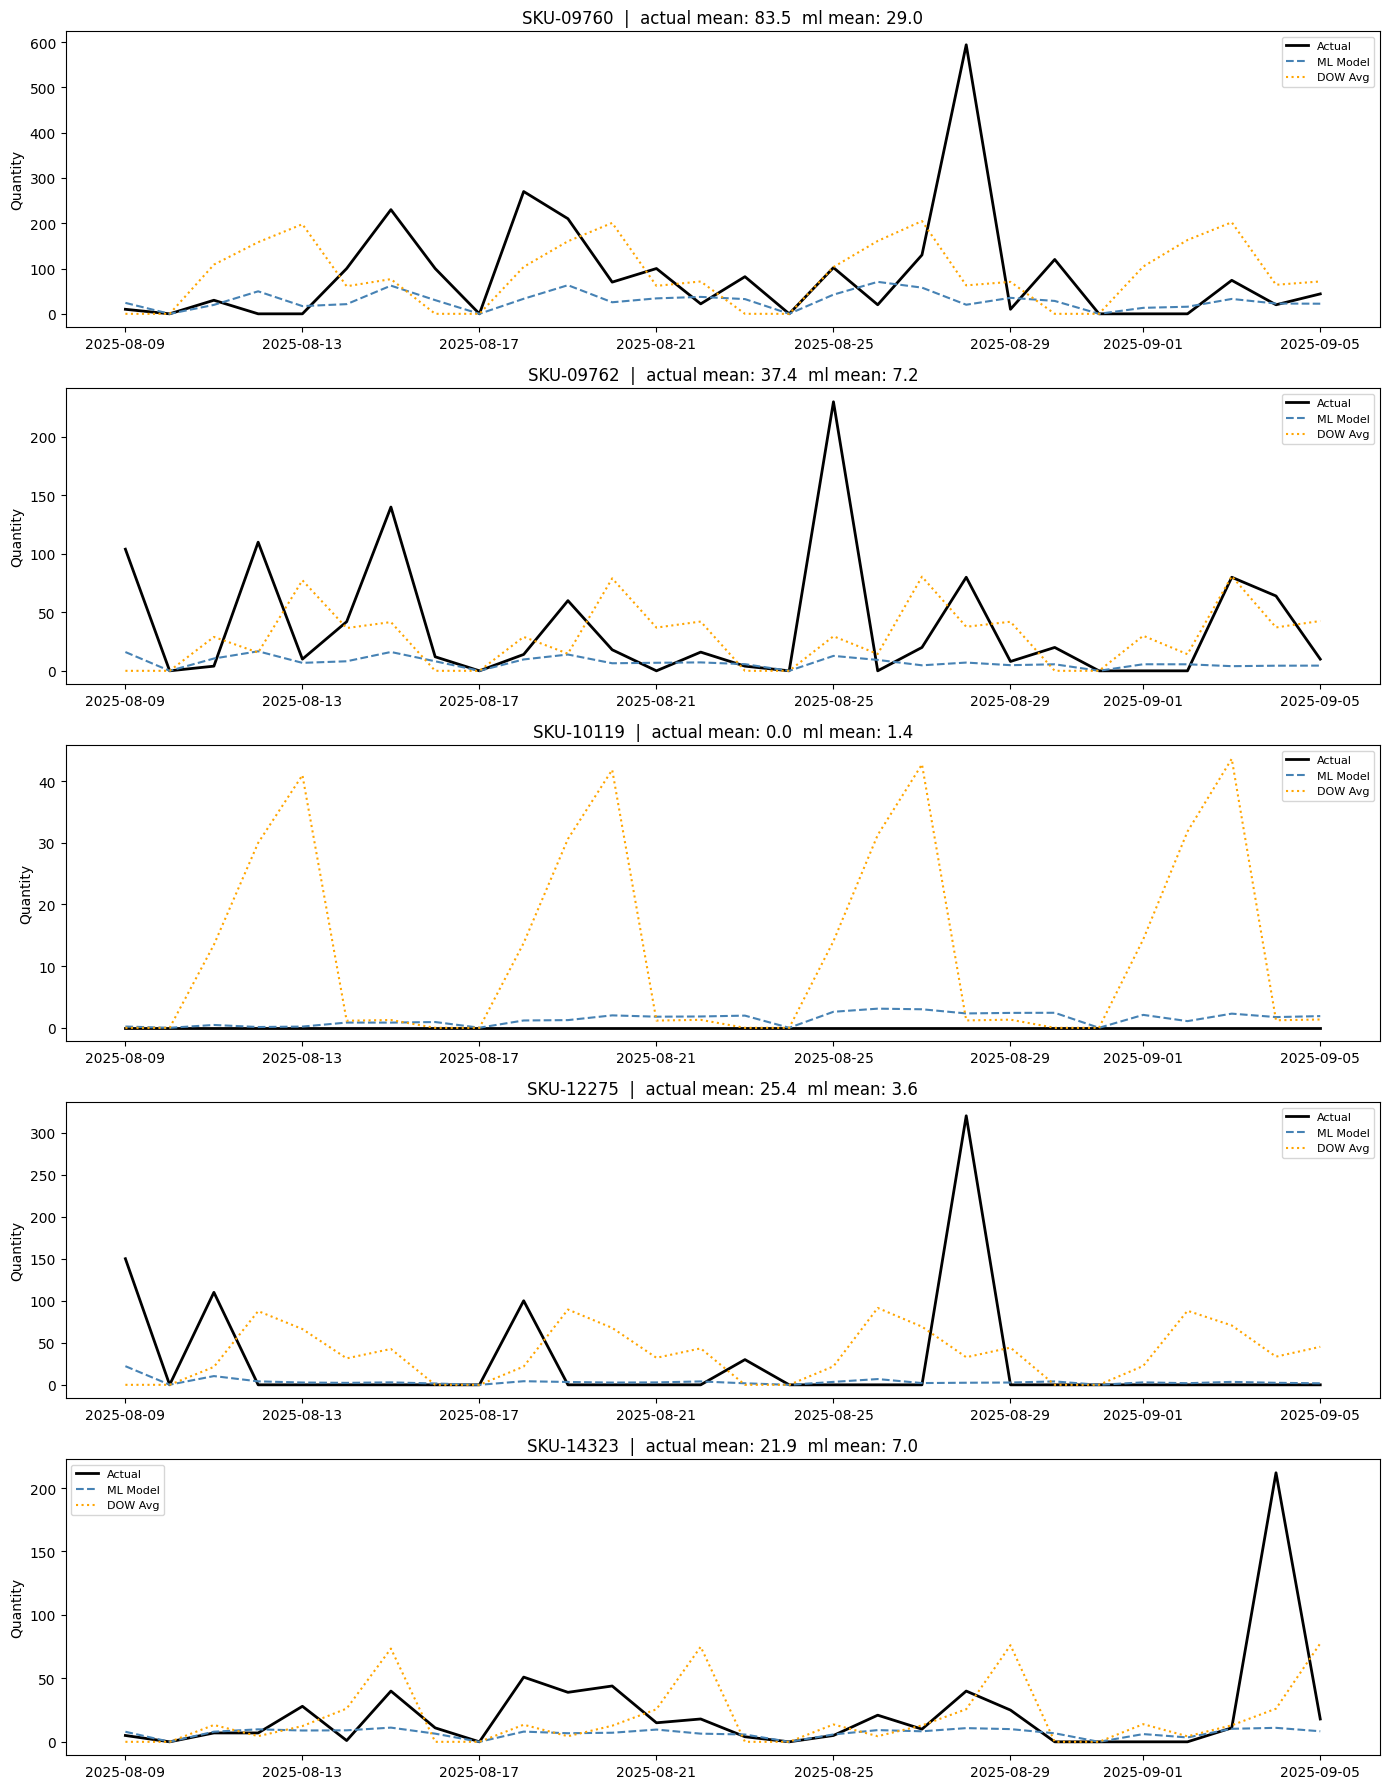

Saved → ../output/eval_top5.png


In [16]:
top5 = weights.sort_values(ascending=False).head(5).index

fig, axes = plt.subplots(5, 1, figsize=(14, 18))
for ax, sku in zip(axes, top5):
    ax.plot(VAL_DATES, actual[sku].values,
            label='Actual',   color='black',     linewidth=2)
    ax.plot(VAL_DATES, pred_ml[sku].values,
            label='ML Model', color='steelblue', linestyle='--')
    ax.plot(VAL_DATES, pred_dow[sku].values,
            label='DOW Avg',  color='orange',    linestyle=':')
    ax.set_title(f'{sku}  |  actual mean: {actual[sku].mean():.1f}  '
                 f'ml mean: {pred_ml[sku].mean():.1f}')
    ax.legend(fontsize=8)
    ax.set_ylabel('Quantity')

os.makedirs('../output', exist_ok=True)
plt.tight_layout()
plt.savefig('../output/eval_top5.png', dpi=150)
plt.show()
print('Saved → ../output/eval_top5.png')

In [17]:
errors = pd.DataFrame({
    'sku'        : TIER_A,
    'actual_mean': [actual[s].mean()  for s in TIER_A],
    'ml_mean'    : [pred_ml[s].mean() for s in TIER_A],
    'mae'        : [np.mean(np.abs(pred_ml[s].values -
                    actual[s].values))  for s in TIER_A],
    'bias'       : [pred_ml[s].mean() -
                    actual[s].mean()    for s in TIER_A],
    'weight'     : [weights[s]          for s in TIER_A],
    'is_top30'   : [s in TOP30          for s in TIER_A],
})
errors = errors.sort_values('weight', ascending=False)

print('TOP 15 HIGHEST WEIGHT SKUs')
print('=' * 70)
print(errors.head(15).to_string(index=False))

over  = (errors['bias'] >  2).sum()
under = (errors['bias'] < -2).sum()
good  = (errors['bias'].abs() <= 2).sum()
print(f'\nOver-predicting  : {over}  SKUs')
print(f'Under-predicting : {under} SKUs')
print(f'Good predictions : {good}  SKUs')

TOP 15 HIGHEST WEIGHT SKUs
      sku  actual_mean   ml_mean       mae       bias  weight  is_top30
SKU-09760    83.500000 29.000851 69.065138 -54.499149  2170.0     False
SKU-09762    37.357143  7.171577 32.734806 -30.185566  1194.0     False
SKU-10119     0.000000  1.385452  1.385452   1.385452   745.0     False
SKU-12275    25.357143  3.564303 25.982338 -21.792840   740.0     False
SKU-14323    21.857143  6.975810 17.290647 -14.881333   715.0     False
SKU-12279     0.000000  2.036851  2.036851   2.036851   649.0     False
SKU-08863     0.428571  1.468252  1.747336   1.039681   563.0     False
SKU-10364     2.964286  1.787125  3.721995  -1.177161   545.0     False
SKU-09497    21.642857  5.484342 19.752907 -16.158515   534.0     False
SKU-14320    15.392857  4.526609 12.350564 -10.866248   522.0     False
SKU-11398     7.464286  3.452775  6.195111  -4.011511   507.0     False
SKU-10117     0.821429  1.770656  1.629849   0.949227   506.0     False
SKU-10384    11.428571  1.353512 12.1

In [18]:
print('QUARTERLY ERROR BREAKDOWN')
print('=' * 50)

for q in [1, 2, 3, 4]:
    q_dates = [d for d in VAL_DATES if d.quarter == q]
    if len(q_dates) == 0:
        print(f'  Q{q} — no dates in val period')
        continue
    q_actual = actual.loc[q_dates, TIER_A]
    q_pred   = pred_ml.loc[q_dates, TIER_A]
    q_mae    = np.mean(np.abs(q_pred.values - q_actual.values))
    q_bias   = (q_pred.values - q_actual.values).mean()
    print(f'  Q{q} — MAE: {q_mae:.3f}  '
          f'Bias: {q_bias:+.3f}  '
          f'Days: {len(q_dates)}')

print()
print('TOP 30 SKUs QUARTERLY BREAKDOWN')
print('=' * 50)
for q in [1, 2, 3, 4]:
    q_dates = [d for d in VAL_DATES if d.quarter == q]
    if len(q_dates) == 0:
        continue
    top30_in_a = [s for s in TOP30 if s in TIER_A]
    if len(top30_in_a) == 0:
        continue
    q_actual = actual.loc[q_dates, top30_in_a]
    q_pred   = pred_ml.loc[q_dates, top30_in_a]
    q_mae    = np.mean(np.abs(q_pred.values - q_actual.values))
    q_bias   = (q_pred.values - q_actual.values).mean()
    print(f'  Q{q} — MAE: {q_mae:.3f}  '
          f'Bias: {q_bias:+.3f}  '
          f'Days: {len(q_dates)}')

QUARTERLY ERROR BREAKDOWN
  Q1 — no dates in val period
  Q2 — no dates in val period
  Q3 — MAE: 5.139  Bias: -3.449  Days: 28
  Q4 — no dates in val period

TOP 30 SKUs QUARTERLY BREAKDOWN


In [19]:
log_entry = {
    'timestamp'     : datetime.now().strftime('%Y-%m-%d %H:%M'),
    'model_version' : 'v2_quarterly_top30',
    'tier_a_skus'   : len(TIER_A),
    'tier_b_skus'   : len(TIER_B),
    'n_features'    : len(FEAT_COLS),
    'wrmsse_dow'    : round(score_dow, 6),
    'wrmsse_ml'     : round(score_ml,  6),
    'improvement'   : round(score_dow - score_ml, 6),
    'leaderboard'   : None,
    'notes'         : 'yearly lags + quarterly features + top30 oversampling'
}

LOG_PATH = '../output/score_tracker.csv'
os.makedirs('../output', exist_ok=True)

if os.path.exists(LOG_PATH):
    log_df  = pd.read_csv(LOG_PATH)
    new_row = pd.DataFrame([log_entry])
    log_df  = pd.concat([log_df, new_row], ignore_index=True)
else:
    log_df = pd.DataFrame([log_entry])

log_df.to_csv(LOG_PATH, index=False)

print('=' * 60)
print('SCORE LOG')
print('=' * 60)
print(log_df[['timestamp', 'model_version', 'wrmsse_ml',
              'leaderboard', 'notes']].to_string(index=False))
print(f'\nSaved → {LOG_PATH}')

SCORE LOG
       timestamp      model_version  wrmsse_ml leaderboard                                                 notes
2026-05-18 15:57 v2_quarterly_top30    2.10609        None yearly lags + quarterly features + top30 oversampling

Saved → ../output/score_tracker.csv


In [21]:
# ── Run this AFTER you get your leaderboard score ─────────────
LEADERBOARD_SCORE = 0.54074   # ← paste your score here e.g. 0.498231

if LEADERBOARD_SCORE is not None:
    log_df = pd.read_csv('../output/score_tracker.csv')
    log_df.loc[log_df.index[-1], 'leaderboard'] = LEADERBOARD_SCORE
    log_df.to_csv('../output/score_tracker.csv', index=False)
    print('✅ Leaderboard score updated!')
    print(log_df[['timestamp', 'model_version',
                  'wrmsse_ml', 'leaderboard']].to_string(index=False))
else:
    print('⚠️ Set LEADERBOARD_SCORE first then re-run this cell')

✅ Leaderboard score updated!
       timestamp      model_version  wrmsse_ml  leaderboard
2026-05-18 15:57 v2_quarterly_top30    2.10609      0.54074


In [22]:
import os
from datetime import datetime

# ── Score to log ───────────────────────────────────────────────
log_entry = {
    'timestamp'       : datetime.now().strftime('%Y-%m-%d %H:%M'),
    'model_version'   : 'v2_quarterly_top30',   # change this each run
    'tier_a_skus'     : len(TIER_A),
    'tier_b_skus'     : len(TIER_B),
    'lag_days'        : str(LAG_DAYS),
    'n_features'      : len(FEAT_COLS),
    'wrmsse_dow'      : round(score_dow, 6),
    'wrmsse_ml'       : round(score_ml,  6),
    'improvement'     : round(score_dow - score_ml, 6),
    'leaderboard'     : None,    # fill this in manually after submitting
    'notes'           : 'added yearly lags + quarterly features + top30 oversampling'
}

# ── Load existing log or create new ───────────────────────────
LOG_PATH = '../output/score_tracker.csv'

if os.path.exists(LOG_PATH):
    log_df = pd.read_csv(LOG_PATH)
    new_row = pd.DataFrame([log_entry])
    log_df  = pd.concat([log_df, new_row], ignore_index=True)
else:
    log_df = pd.DataFrame([log_entry])

# ── Save ───────────────────────────────────────────────────────
os.makedirs('../output', exist_ok=True)
log_df.to_csv(LOG_PATH, index=False)

# ── Display ────────────────────────────────────────────────────
print('=' * 60)
print('SCORE LOG UPDATED')
print('=' * 60)
print(log_df.to_string(index=False))
print(f'\nSaved → {LOG_PATH}')

SCORE LOG UPDATED
       timestamp      model_version  tier_a_skus  tier_b_skus  n_features  wrmsse_dow  wrmsse_ml  improvement leaderboard                                                       notes                                            lag_days
2026-05-18 15:57 v2_quarterly_top30          125          408          61    2.382255    2.10609     0.276165     0.54074       yearly lags + quarterly features + top30 oversampling                                                 NaN
2026-05-18 16:02 v2_quarterly_top30          125          408          61    2.382255    2.10609     0.276165        None added yearly lags + quarterly features + top30 oversampling [1, 2, 3, 7, 14, 21, 28, 35, 42, 56, 364, 365, 366]

Saved → ../output/score_tracker.csv
